In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd


df = pd.read_csv("../data/cleaned_house_data.csv") # Load your dataset here


In [15]:

X = df.drop(columns=["price"])
y = df["price"]





In [16]:
# Scale for Linear Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    "Linear Regression": (LinearRegression(), X_scaled),
    "Random Forest": (RandomForestRegressor(n_estimators=100, random_state=42), X),
    "Gradient Boosting": (GradientBoostingRegressor(n_estimators=100, random_state=42), X)
}

for name, (model, data) in models.items():
    scores = cross_val_score(model, data, y, cv=5, scoring='r2')
    print(f"\n{name}")
    print(f"R² scores: {scores}")
    print(f"Mean R²: {scores.mean():.4f}")
    print(f"Std R²:  {scores.std():.4f}")


Linear Regression
R² scores: [0.90420912 0.90955345 0.90881149 0.90879537 0.90329023]
Mean R²: 0.9069
Std R²:  0.0026

Random Forest
R² scores: [0.99846012 0.99885315 0.99883825 0.99812754 0.99782845]
Mean R²: 0.9984
Std R²:  0.0004

Gradient Boosting
R² scores: [0.99314565 0.99312192 0.99350116 0.99278702 0.99190548]
Mean R²: 0.9929
Std R²:  0.0005


In [17]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X, y)

print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best R²: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'max_features': None, 'max_depth': 30}
Best R²: 0.9985


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Untuned
rf_untuned = RandomForestRegressor(n_estimators=100, random_state=42)
rf_untuned.fit(X_train, y_train)
untuned_r2 = r2_score(y_test, rf_untuned.predict(X_test))

# Tuned
rf_tuned = RandomForestRegressor(**random_search.best_params_, random_state=42)
rf_tuned.fit(X_train, y_train)
tuned_r2 = r2_score(y_test, rf_tuned.predict(X_test))

print(f"Untuned R²: {untuned_r2:.4f}")
print(f"Tuned R²:   {tuned_r2:.4f}")
print(f"Improvement: {(tuned_r2 - untuned_r2):.4f}")

Untuned R²: 0.9987
Tuned R²:   0.9986
Improvement: -0.0000


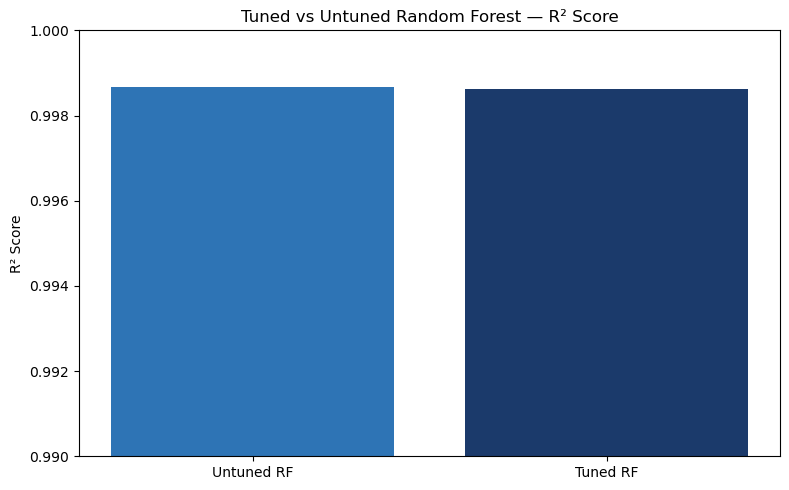

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(["Untuned RF", "Tuned RF"], [untuned_r2, tuned_r2], 
        color=["#2E74B5", "#1B3A6B"])
plt.title("Tuned vs Untuned Random Forest — R² Score")
plt.ylabel("R² Score")
plt.ylim(0.99, 1.0)
plt.tight_layout()
plt.savefig("tuned_vs_untuned.png")
plt.show()

In [ ]:
# Observation 1: Cross-validation confirmed Random Forest's dominance with 
# Mean R² of 0.9984 and Std of only 0.0004 across 5 folds — the original 
# result was not a lucky split.

# Observation 2: Hyperparameter tuning produced negligible improvement and 
# the tuned model actually performed marginally worse on the test set 
# (0.9986 vs 0.9987) — indicating default settings were already near optimal.

# Observation 3: The minimal gain from tuning suggests performance is 
# constrained by feature quality not model complexity. When price_per_sqft 
# directly encodes the target relationship, algorithmic tuning has little 
# room to improve.